# Case Study of Binary Adsorption of CO2 and N2 on Cu-BTC

This Jupyter notebook walks through the case study described in the paper. The goal is to demonstrate how to use pyRAST to analyze a real dataset from GCMC simulations.

First, we will load the necessary modules and dataset. pyRAST requires isotherm data to be in a pandas DataFrame.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyrast.activity_coefficients import ActivityCoefficient
from pyrast.calculations.iast import iast
from pyrast.calculations.rast import rast, reverse_rast
from pyrast.isotherms import CubicIsotherm, ModelIsotherm
from pyrast.utilities.plotting import plot_isotherm, plot_spreading_pressure

# Load binary data
co2_n2_binary = pd.read_csv('../test_data/Cu-BTC_CO2_N2_298K_isotherm.csv')

# Load pure component data
co2_pure = pd.read_csv('../test_data/Cu-BTC_CO2_298K_isotherm.csv')
n2_pure = pd.read_csv('../test_data/Cu-BTC_N2_298K_isotherm.csv')

Next, let's fit isotherms and visualize the results. To showcase the capabilities of pyRAST, we will fit three isotherms: Langmuir, aNRTL-VST, and the CubicIsotherm.

To fit an isotherm to an analytical model, we can use the ModelIsotherm class. This class takes in the dataset, the column names for loading and pressure (or fugacity), and the name of the model to fit. There are many additional parameters that can be passed to the fit, such as a different initial guess, parameter bounds, and more. We will use the default settings for this example. Note that there is also an option to set model parameters, which will bypass the fitting process. Also, VST models are implemented to use interpolators as they are implicit functions of loading. There are three optional parameters specific to VST models that set the number of points to interpolate between, the maximum pressure to interpolate to, and options to pass to the root solving used to find the loading when building the interpolators.

You can also use an interpolator isotherm, such as the CubicIsotherm, which simply creates an interpolator of the data. This guarantees that the isotherm will fit the data perfectly, but the behavior between isotherm points is less physical. A linear interpolation method is also available through InterpolatorIsotherm, but we suggest using the CubicIsotherm for smoother behavior.

We will start with creating isotherms for CO2 to demonstrate the available fitting options.

Langmuir Isotherm with parameters: {'M': np.float64(20.34386540229435), 'K': np.float64(1.4853854243904581e-06)}, guess: {'M': np.float64(25.347482600000003), 'K': np.float64(3.3928533709848526e-06)}, and RMSE: 0.8003503568618778


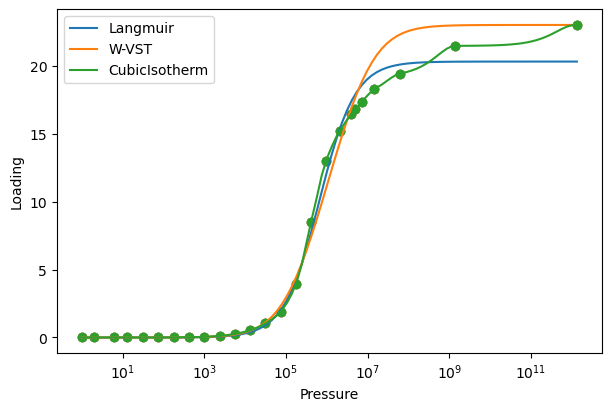

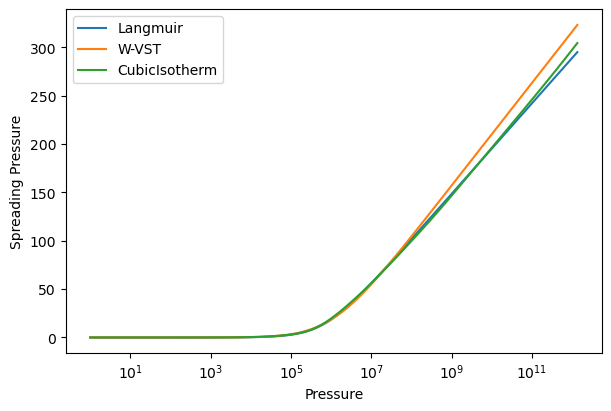

In [3]:
# Fit isotherms with default settings
co2_langmuir = ModelIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]',
                             'CO2_fugacity[Pa]', 'Langmuir')
co2_wvst = ModelIsotherm(df=co2_pure, loading_key='CO2_uptake_absolute[mol/kg]',
                          pressure_key='CO2_fugacity[Pa]', model='W-VST')
co2_cubic = CubicIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]', 'CO2_fugacity[Pa]')

# Print information about the isotherm
print(co2_langmuir)

# Visualize the fits
plot_isotherm([co2_langmuir, co2_wvst, co2_cubic], xlogscale=True)
# Compare spreading pressures
plot_spreading_pressure([co2_langmuir, co2_wvst, co2_cubic], xlogscale=True)

Notice how the fits are not perfect, especially at higher fugacities. We are currently showing the fits only for the data in the isotherm, however it is common that IAST or RAST calculations require extrapolation beyond the range of the data. To get a better idea of how the isotherm fits will behave when extrapolating, we can plot the fits to a higher pressure range. This can be done by passing in a pressure range to the plotting function. Let's see how this looks for the CO2 isotherms.

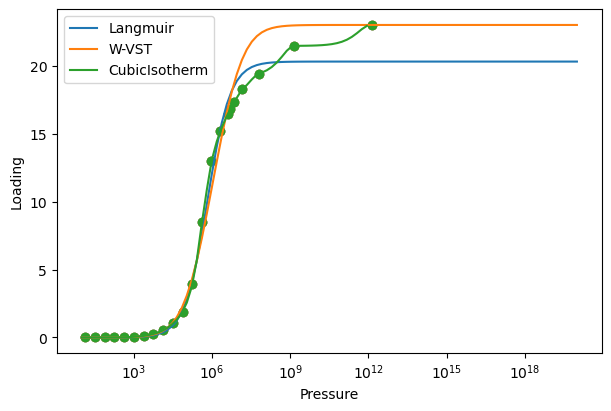

In [4]:
pressures = np.logspace(1, 20, 100)
plot_isotherm([co2_langmuir, co2_wvst, co2_cubic], xlogscale=True, pressures=pressures)

The CubicIsotherm by default does not extrapolate data. To extrapolate, we pass an extrapolation method when creating the isotherm. The two options are to use a linear fit to the last two points of the isotherm, or to fit an analytical model to the whole isotherm and use it for extrapolation. This is done by passing the 'extrap_method' parameter when creating the isotherm. Let's compare how these methods look for the CubicIsotherm.

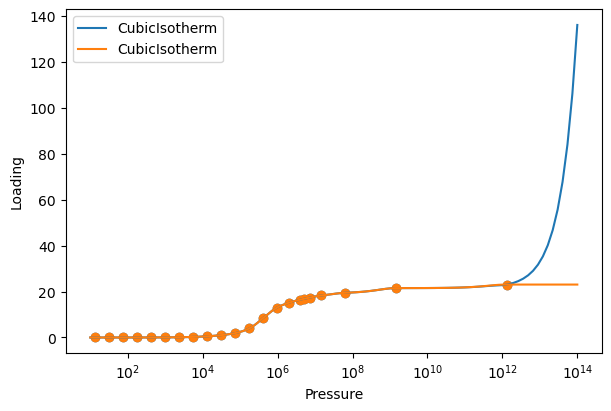

In [5]:
linear_extrap = CubicIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]',
                              'CO2_fugacity[Pa]', extrap_method='linear')
model_extrap = CubicIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]',
                             'CO2_fugacity[Pa]', extrap_method='Langmuir')
pressures = np.logspace(1, 14, 100)
plot_isotherm([linear_extrap, model_extrap], xlogscale=True, pressures=pressures)

We can see that the linear extrapolation method can quickly result in significantly overestimating the loading at high pressures. The model extrapolation correctly captures saturation behavior. To demonstrate how the isotherm is built, let's create an isotherm using fugacity only up to 10 bar.

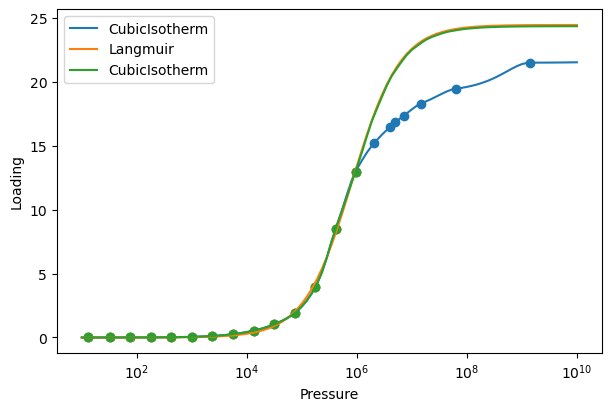

In [6]:
co2_cubic = CubicIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]', 'CO2_fugacity[Pa]')
shortened_data = co2_pure[co2_pure['CO2_fugacity[Pa]'] <= 1e6]
shortened_extrap = CubicIsotherm(shortened_data, 'CO2_uptake_absolute[mol/kg]',
                                'CO2_fugacity[Pa]', extrap_method='Langmuir')
shortened_langmuir = ModelIsotherm(shortened_data, 'CO2_uptake_absolute[mol/kg]',
                                 'CO2_fugacity[Pa]', 'Langmuir')
pressures = np.logspace(1, 10, 100)
plot_isotherm([co2_cubic, shortened_langmuir, shortened_extrap], xlogscale=True,
              pressures=pressures)

The original data is in blue and the extrapolated isotherm is in green. Although the model fit does not exactly match the saturation loading of the original data, it better captures the shape of the isotherm and produces more reasonable extrapolated values at high pressures. Like the normal CubicIsotherm, the extrapolated isotherm has a maximum pressure it can be evaluted to, which is by default 1e40. If you find that you need a higher maximum pressure, you can set extrap_p to a higher value when creating the isotherm.

Let's fit CubicIsotherms with Langmuir extrapolation for both CO2 and N2, and then use them for our calculations.

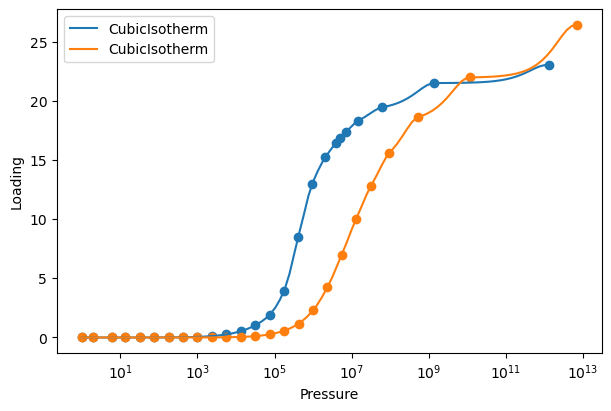

In [7]:
co2_isotherm = CubicIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]',
                             'CO2_fugacity[Pa]', extrap_method='Langmuir')
n2_isotherm = CubicIsotherm(n2_pure, 'N2_uptake_absolute[mol/kg]',
                            'N2_fugacity[Pa]', extrap_method='Langmuir')
plot_isotherm([co2_isotherm, n2_isotherm], xlogscale=True)

# Ideal Adsorbed Solution Theory (IAST) Calculations
Now that we have our isotherms, we can use them to perform IAST calculations. The IAST method requires pure component isotherms to predict the adsorption of mixtures. We will use the isotherms we just created for CO2 and N2 to predict the binary adsorption of a mixture of these gases across a range of pressures and compositions.

In pyRAST, the IAST calculation is performed using the 'iast' function. The required inputs are the partial pressures of the components in the gas phase and a list of pure component isotherms. The function will return the predicted loadings of each component in the adsorbed phase. Let's see how this works in practice.

Note: We created the isotherms using fugacity, not pressure. The IAST function does not distinguish between pressure and fugacity. It is recommended to use fugacity for all calculations, if possible.

In [8]:
# Start with one calculation to demonstrate the function, and then we can loop through a
# range of conditions. Start with a 50/50 mixture at 10 bar total fugacity.

partial_fugacities = [5e5, 5e5]
isotherms = [co2_isotherm, n2_isotherm]
loadings = iast(partial_fugacities, isotherms)
print(f"Predicted loadings: {loadings} mol/kg")

# With the verbose keyword, we can get more information about the calculation.
loadings = iast(partial_fugacities, isotherms, verbose=True)

Predicted loadings: [9.1319715  0.66377813] mol/kg
Performing IAST calculation for 2 components.
Component 0: Partial Pressure = 500000.0, Isotherm Model = CubicIsotherm
Component 1: Partial Pressure = 500000.0, Isotherm Model = CubicIsotherm
Component  0
	p =  500000.0
	p^0 =  536343.637829884
	Loading:  9.131971496765708
	x =  0.93223814870456
	Spreading pressure =  12.502853134175158
Component  1
	p =  500000.0
	p^0 =  7378783.0533143645
	Loading:  0.6637781295025508
	x =  0.0677618512954399
	Spreading pressure =  12.502853134175155


With the verbose keyword, we can see why extrapolation is often necessary for IAST calculations. IAST works by equating the spreading pressures of each component in the mixture, which for CO2 requires a P^0 of 5.36 bar, but for N2 requires a P^0 of 73.7 bar. Depending on the selectivity of the mixture, the P^0 of one component can be orders of magnitude higher than the other, which may require a pressure beyond the range of the data. Let's now loop through a range of pressures and compositions to see how IAST predictions match up with GCMC data.

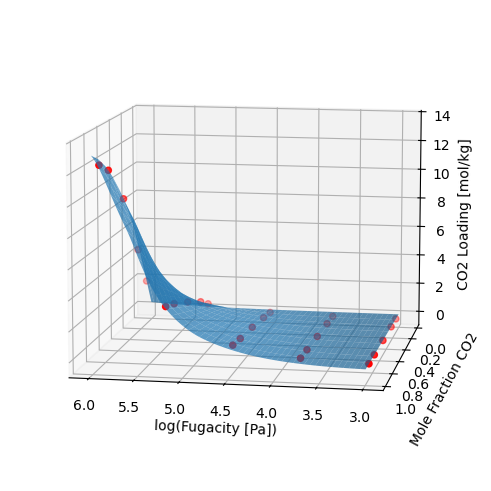

In [9]:
fugacity = np.logspace(3, 6, 100)
compositions = np.linspace(0.01, 0.99, 10)
load = np.zeros((len(compositions), len(fugacity)))
fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, layout='constrained')
for i, x in enumerate(compositions):
    for j, f in enumerate(fugacity):
        partial_fugacities = [x * f, (1 - x) * f]
        loadings = iast(partial_fugacities, isotherms)
        load[i, j] = loadings[0]
X, Y = np.meshgrid(fugacity, compositions)
X = np.log10(X)
ax.plot_surface(X, Y, load, alpha=0.7)
ax.set_xlabel('log(Fugacity [Pa])')
ax.set_ylabel('Mole Fraction CO2')
ax.set_zlabel('CO2 Loading [mol/kg]')

# Plot original data
X = np.log10(co2_n2_binary['CO2_fugacity[Pa]'] + co2_n2_binary['N2_fugacity[Pa]'])
Y = co2_n2_binary['y_co2']
Z = co2_n2_binary['CO2_uptake_absolute[mol/kg]']
ax.scatter(X, Y, Z, color='red', label='GCMC Data')
ax.view_init(elev=10, azim=100)

plt.show()

IAST overall captures the trends of the mixture adsorption, but there are some deviations from the GCMC data. We can see this more closely by focusing on a 50/50 mixture and plotting the selectivity of CO2 over N2. 

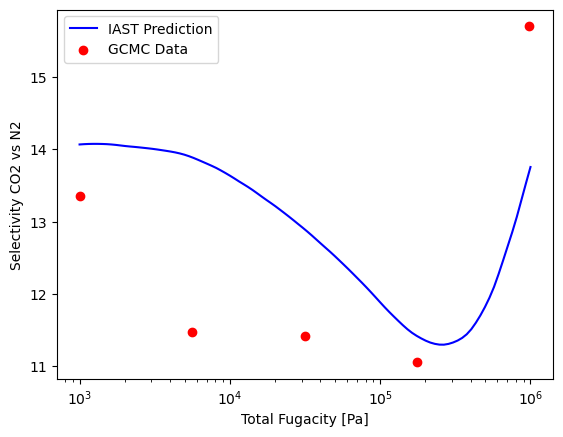

In [10]:
# 50/50 mixture selectivity
fugacities = np.logspace(3, 6, 100)
selectivity = np.zeros(len(fugacities))
for i, f in enumerate(fugacities):
    partial_fugacities = [0.5 * f, 0.5 * f]
    loadings = iast(partial_fugacities, isotherms)
    selectivity[i] = (loadings[0] / loadings[1])
fig, ax = plt.subplots()
ax.plot(fugacities, selectivity, label='IAST Prediction', color='blue')
ax.set_xscale('log')
ax.set_xlabel('Total Fugacity [Pa]')
ax.set_ylabel('Selectivity CO2 vs N2')

# Plot original data
data = co2_n2_binary[co2_n2_binary['y_co2'] == 0.5]
selectivity = data['CO2_uptake_absolute[mol/kg]'] / data['N2_uptake_absolute[mol/kg]']
ax.scatter(data['CO2_fugacity[Pa]'] + data['N2_fugacity[Pa]'], selectivity,
           color='red', label='GCMC Data')
ax.legend()


plt.show()

Thus, IAST captures the trend of the data, but the error in selectivity can be >30%. Let's now fit an activity coefficient model to the binary data and see if we can improve our predictions.

# Activity Coefficient Fitting and Real Adsorbed Solution Theory (RAST) Calculations
pyRAST aims to make activity coefficient fitting as simple as possible. The ActivityCoefficient class requires binary adsorption data, pure component isotherms, and the name of the model to fit. The binary adsorption data is input similar to IAST or RAST calculations. Partial fugacities are input as a 2D array with each row corresponding to a data point and each column corresponding to a component. The same is true for the loadings. In pyRAST, it is also possible to fit a model to total loadings. In that case, the loading array is a 1D array of total loadings, and the partial fugacity input is the same. Pure component isotherms must always be specified as a 1D list. The model name is passed as a string.

There are many optional parameters that are fully described in the documentation. The most important parameters are 'total_loading', which must be set to True if fitting to total loadings, and 'model_parameters', which can be used to set the model parameters directly, bypassing the fitting process. The 'verbose' parameter can be set to True to print information about the fitting process.

For simplicity, we will use all of the binary data in the dataset to fit the activity coefficient model. We will compare two models here, aNRTL and Van Laar. Let's see how these models fit the data.

In [11]:
# First we will fit the aNRTL model and visualize the results
partial_fug = np.array([co2_n2_binary['CO2_fugacity[Pa]'].values,
                        co2_n2_binary['N2_fugacity[Pa]'].values])
partial_fug = partial_fug.T
loadings = np.array([co2_n2_binary['CO2_uptake_absolute[mol/kg]'].values,
            co2_n2_binary['N2_uptake_absolute[mol/kg]'].values])
loadings = loadings.T
isotherms = [co2_isotherm, n2_isotherm]
ac = ActivityCoefficient(partial_fug, loadings, isotherms, 'aNRTL')
print(ac)

aNRTL activity coefficient model with parameters: {'t12': np.float64(0.35926880312556553), 'C': np.float64(116.88846098736295)}


Fitting activity coefficients is as simple as that! To visualize the fit, we can use real adsorbed solution theory (RAST) calculations to generate an x-y diagram at a specific total fugacity and plot selectivity as a function of total fugacity. The RAST calculation is performed using the 'rast' function, which takes in the partial fugacities of the components in the gas phase, a list of pure component isotherms, and an instance of the ActivityCoefficient class. The function will return the predicted loadings of each component in the adsorbed phase. Let's see how this works in practice.

We will first show a sample RAST calculation, then create the plots.

In [12]:
partial_fugacities = [5e5, 5e5]
isotherms = [co2_isotherm, n2_isotherm]
loadings = rast(partial_fugacities, isotherms, ac)
print(f"Predicted loadings: {loadings} mol/kg")

# With the verbose keyword, we can get more information about the calculation.
loadings = rast(partial_fugacities, isotherms, ac, verbose=True)

Predicted loadings: [9.11927749 0.68577407] mol/kg
Performing RAST calculation for 2 components.
Component 0: Partial Pressure = 500000.0, Isotherm Model = CubicIsotherm
Component 1: Partial Pressure = 500000.0, Isotherm Model = CubicIsotherm
Component  0
	p =  500000.0
	p^0 =  537718.1284465629
	Loading:  9.119277486369585
	x =  0.9300591063821719
	Spreading pressure =  12.528305275167096
Component  1
	p =  500000.0
	p^0 =  7402131.809863134
	Loading:  0.685774067657529
	x =  0.06994089361782795
	Spreading pressure =  12.528305275167098


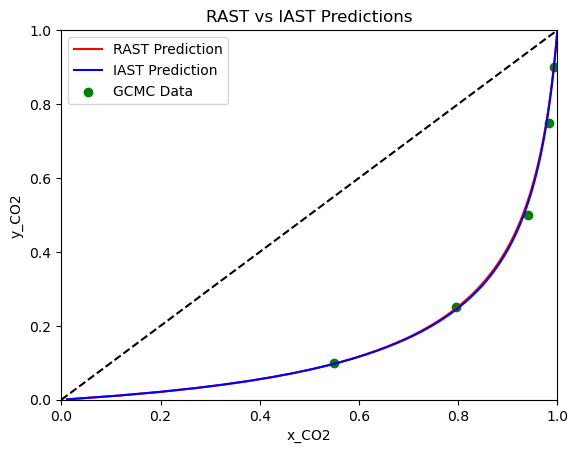

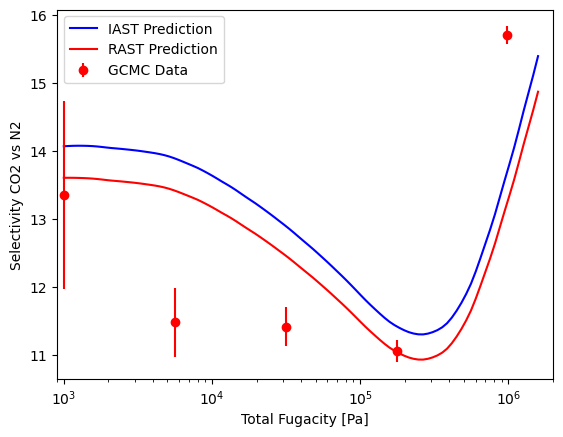

In [13]:
y_co2 = np.linspace(0.001, 0.999, 100)
total_f = 1e6
x = np.zeros(len(y_co2))
fig, ax = plt.subplots()

for i, y in enumerate(y_co2):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = rast(partial_fugacities, isotherms, ac)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_co2, label='RAST Prediction', color='red')

for i, y in enumerate(y_co2):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = iast(partial_fugacities, isotherms)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_co2, label='IAST Prediction', color='blue')

# Plot original data
data = co2_n2_binary[co2_n2_binary['total_pressure[Pa]'] == total_f]
x = data['CO2_uptake_absolute[mol/kg]']/(data['CO2_uptake_absolute[mol/kg]'] + data['N2_uptake_absolute[mol/kg]'])
y = data['y_co2']
ax.scatter(x, y, color='green', label='GCMC Data')

ax.set_xlabel('x_CO2')
ax.set_ylabel('y_CO2')
ax.legend()
ax.set_title('RAST vs IAST Predictions')
ax.axline((0, 0), slope=1, color='black', linestyle='--')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()

# 50/50 mixture selectivity
y = 0.5
fugacities = np.logspace(3, 6.2, 100)
selectivity = np.zeros(len(fugacities))
for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = iast(partial_fugacities, isotherms)
    selectivity[i] = (loadings[0] / loadings[1])
fig, ax = plt.subplots()
ax.plot(fugacities, selectivity, label='IAST Prediction', color='blue')
ax.set_xscale('log')
ax.set_xlabel('Total Fugacity [Pa]')
ax.set_ylabel('Selectivity CO2 vs N2')

for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = rast(partial_fugacities, isotherms, ac)
    selectivity[i] = (loadings[0] / loadings[1])
ax.plot(fugacities, selectivity, label='RAST Prediction', color='red')

# Plot original data
data = co2_n2_binary[co2_n2_binary['y_co2'] == y]
error1 = (data['CO2_uptake_absolute_uncertainty[mol/kg]'] / data['CO2_uptake_absolute[mol/kg]'])**2
error2 = (data['N2_uptake_absolute_uncertainty[mol/kg]'] / data['N2_uptake_absolute[mol/kg]'])**2
selectivity = data['CO2_uptake_absolute[mol/kg]'] / data['N2_uptake_absolute[mol/kg]']
error = selectivity * np.sqrt(error1 + error2)
ax.errorbar(data['CO2_fugacity[Pa]'] + data['N2_fugacity[Pa]'], selectivity,
            yerr=error, fmt='o', color='red', label='GCMC Data')
ax.legend()
ax.set_xlim(9e2, 2e6)

plt.show()


Notice how there is very little difference between IAST and RAST on the x-y diagram, but the selectivity plot shows that RAST is slightly more accurate at the lower fugacity range. Let's repeat this using the Van Laar model and see how it compares to the aNRTL model.

VanLaar activity coefficient model with parameters: {'A12': np.float64(585.711439976474), 'A21': np.float64(1445.4110502290957), 'C': np.float64(1.1151512136329737e-05)}


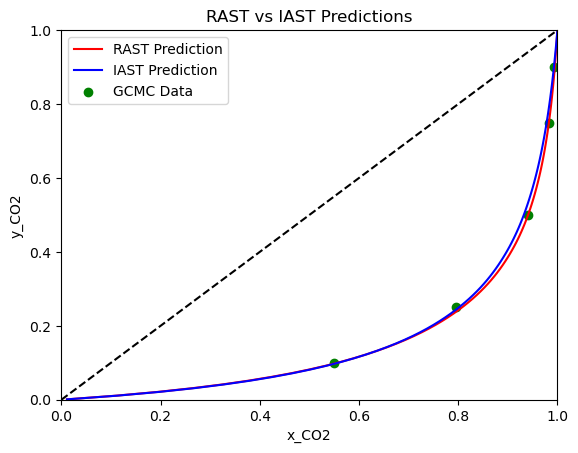

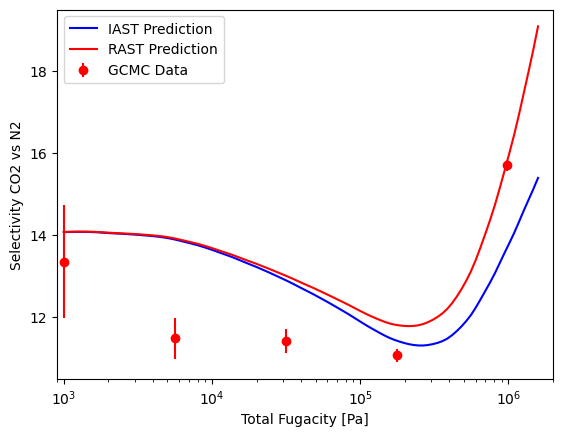

In [14]:
partial_fug = np.array([co2_n2_binary['CO2_fugacity[Pa]'].values,
                        co2_n2_binary['N2_fugacity[Pa]'].values])
partial_fug = partial_fug.T
loadings = np.array([co2_n2_binary['CO2_uptake_absolute[mol/kg]'].values,
            co2_n2_binary['N2_uptake_absolute[mol/kg]'].values])
loadings = loadings.T
isotherms = [co2_isotherm, n2_isotherm]
ac = ActivityCoefficient(partial_fug, loadings, isotherms, 'VanLaar')
print(ac)

y_co2 = np.linspace(0.001, 0.999, 100)
total_f = 1e6
x = np.zeros(len(y_co2))
fig, ax = plt.subplots()

for i, y in enumerate(y_co2):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = rast(partial_fugacities, isotherms, ac)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_co2, label='RAST Prediction', color='red')

for i, y in enumerate(y_co2):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = iast(partial_fugacities, isotherms)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_co2, label='IAST Prediction', color='blue')

# Plot original data
data = co2_n2_binary[co2_n2_binary['total_pressure[Pa]'] == total_f]
x = data['CO2_uptake_absolute[mol/kg]']/(data['CO2_uptake_absolute[mol/kg]'] + data['N2_uptake_absolute[mol/kg]'])
y = data['y_co2']
ax.scatter(x, y, color='green', label='GCMC Data')

ax.set_xlabel('x_CO2')
ax.set_ylabel('y_CO2')
ax.legend()
ax.set_title('RAST vs IAST Predictions')
ax.axline((0, 0), slope=1, color='black', linestyle='--')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()

# 50/50 mixture selectivity
y = 0.5
fugacities = np.logspace(3, 6.2, 100)
selectivity = np.zeros(len(fugacities))
for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = iast(partial_fugacities, isotherms)
    selectivity[i] = (loadings[0] / loadings[1])
fig, ax = plt.subplots()
ax.plot(fugacities, selectivity, label='IAST Prediction', color='blue')
ax.set_xscale('log')
ax.set_xlabel('Total Fugacity [Pa]')
ax.set_ylabel('Selectivity CO2 vs N2')

for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = rast(partial_fugacities, isotherms, ac)
    selectivity[i] = (loadings[0] / loadings[1])
ax.plot(fugacities, selectivity, label='RAST Prediction', color='red')

# Plot original data
data = co2_n2_binary[co2_n2_binary['y_co2'] == y]
error1 = (data['CO2_uptake_absolute_uncertainty[mol/kg]'] / data['CO2_uptake_absolute[mol/kg]'])**2
error2 = (data['N2_uptake_absolute_uncertainty[mol/kg]'] / data['N2_uptake_absolute[mol/kg]'])**2
selectivity = data['CO2_uptake_absolute[mol/kg]'] / data['N2_uptake_absolute[mol/kg]']
error = selectivity * np.sqrt(error1 + error2)
ax.errorbar(data['CO2_fugacity[Pa]'] + data['N2_fugacity[Pa]'], selectivity,
            yerr=error, fmt='o', color='red', label='GCMC Data')
ax.legend()
ax.set_xlim(9e2, 2e6)

plt.show()


With the Van Laar model, we can see that the RAST predictions are better on the x-y diagram, and the selectivity of RAST is more accurate at higher fugacities. At lower fugacities, the Van Laar model converges to the IAST predictions. Overall, we see a relatively small difference between IAST and RAST using the CubicIsotherm. This is because the CubicIsotherm fits the pure component data very well, which limits the improvement that can be achieved by fitting an activity coefficient model. However, if we were to use a less accurate isotherm fit, such as the Langmuir, we would see a much larger difference between IAST and RAST predictions. Let's see how this looks using the Langmuir isotherm and aNRTL model instead of the CubicIsotherm.

aNRTL activity coefficient model with parameters: {'t12': np.float64(1.706271865525217), 'C': np.float64(238.60867298617373)}


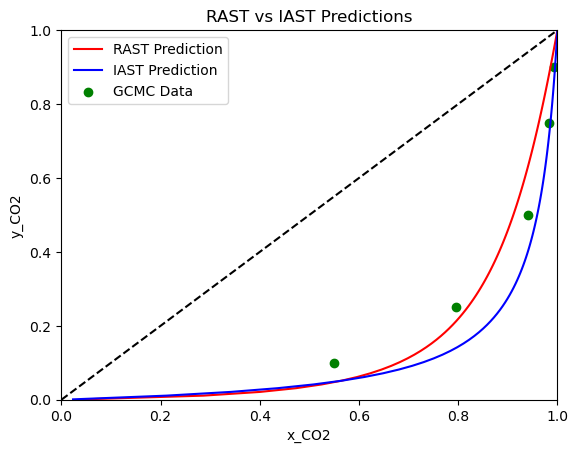

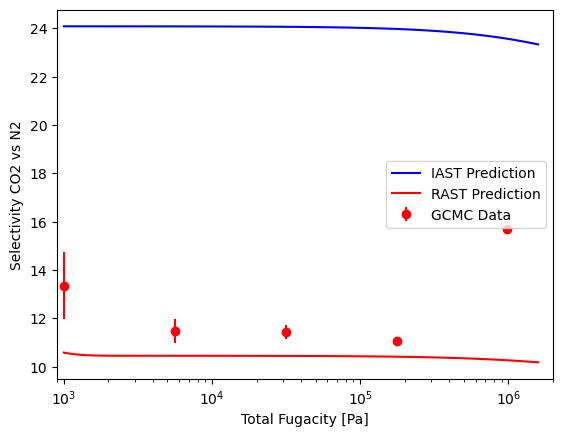

In [15]:
co2_isotherm = ModelIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]',
                             'CO2_fugacity[Pa]', model='Langmuir')
n2_isotherm = ModelIsotherm(n2_pure, 'N2_uptake_absolute[mol/kg]',
                            'N2_fugacity[Pa]', model='Langmuir')

partial_fug = np.array([co2_n2_binary['CO2_fugacity[Pa]'].values,
                        co2_n2_binary['N2_fugacity[Pa]'].values])
partial_fug = partial_fug.T
loadings = np.array([co2_n2_binary['CO2_uptake_absolute[mol/kg]'].values,
            co2_n2_binary['N2_uptake_absolute[mol/kg]'].values])
loadings = loadings.T
isotherms = [co2_isotherm, n2_isotherm]
ac = ActivityCoefficient(partial_fug, loadings, isotherms, 'aNRTL')
print(ac)

y_co2 = np.linspace(0.001, 0.999, 100)
total_f = 1e6
x = np.zeros(len(y_co2))
fig, ax = plt.subplots()

for i, y in enumerate(y_co2):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = rast(partial_fugacities, isotherms, ac)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_co2, label='RAST Prediction', color='red')

for i, y in enumerate(y_co2):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = iast(partial_fugacities, isotherms)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_co2, label='IAST Prediction', color='blue')

# Plot original data
data = co2_n2_binary[co2_n2_binary['total_pressure[Pa]'] == total_f]
x = data['CO2_uptake_absolute[mol/kg]']/(data['CO2_uptake_absolute[mol/kg]'] + data['N2_uptake_absolute[mol/kg]'])
y = data['y_co2']
ax.scatter(x, y, color='green', label='GCMC Data')

ax.set_xlabel('x_CO2')
ax.set_ylabel('y_CO2')
ax.legend()
ax.set_title('RAST vs IAST Predictions')
ax.axline((0, 0), slope=1, color='black', linestyle='--')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()

# 50/50 mixture selectivity
y = 0.5
fugacities = np.logspace(3, 6.2, 100)
selectivity = np.zeros(len(fugacities))
for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = iast(partial_fugacities, isotherms)
    selectivity[i] = (loadings[0] / loadings[1])
fig, ax = plt.subplots()
ax.plot(fugacities, selectivity, label='IAST Prediction', color='blue')
ax.set_xscale('log')
ax.set_xlabel('Total Fugacity [Pa]')
ax.set_ylabel('Selectivity CO2 vs N2')

for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = rast(partial_fugacities, isotherms, ac)
    selectivity[i] = (loadings[0] / loadings[1])
ax.plot(fugacities, selectivity, label='RAST Prediction', color='red')

# Plot original data
data = co2_n2_binary[co2_n2_binary['y_co2'] == y]
error1 = (data['CO2_uptake_absolute_uncertainty[mol/kg]'] / data['CO2_uptake_absolute[mol/kg]'])**2
error2 = (data['N2_uptake_absolute_uncertainty[mol/kg]'] / data['N2_uptake_absolute[mol/kg]'])**2
selectivity = data['CO2_uptake_absolute[mol/kg]'] / data['N2_uptake_absolute[mol/kg]']
error = selectivity * np.sqrt(error1 + error2)
ax.errorbar(data['CO2_fugacity[Pa]'] + data['N2_fugacity[Pa]'], selectivity,
            yerr=error, fmt='o', color='red', label='GCMC Data')
ax.legend()
ax.set_xlim(9e2, 2e6)

plt.show()


Here, we see a much larger difference between IAST and RAST predictions. The x-y diagram shows slight improvement at lower mole fractions of CO2, but the selectivity plot shows a significant improvement across the entire range of fugacities. With a poor fit of the pure component data, IAST predictions can be significantly off, but RAST can help correct for this and produce more accurate predictions of mixture adsorption. This highlights the importance of fitting accurate isotherms to pure component data, and also the value of using activity coefficient models and RAST when analyzing mixture adsorption data.

We have now seen how to use pyRAST to fit isotherms, perform IAST calculations, fit activity coefficient models, and perform RAST calculations. The case study we went through is just one example of how pyRAST can be used to analyze adsorption data. The flexibility of the package allows for many models and applications. We encourage you to explore the documentation and try out pyRAST on your own datasets!

Additionally, we will quickly demonstrate two more components of pyRAST: fitting to total loading and reverse IAST/RAST calculations. Let's look at total loading fitting first.

aNRTL activity coefficient model with parameters: {'t12': np.float64(1.7801301750775367), 'C': np.float64(3.4981060928008114)}


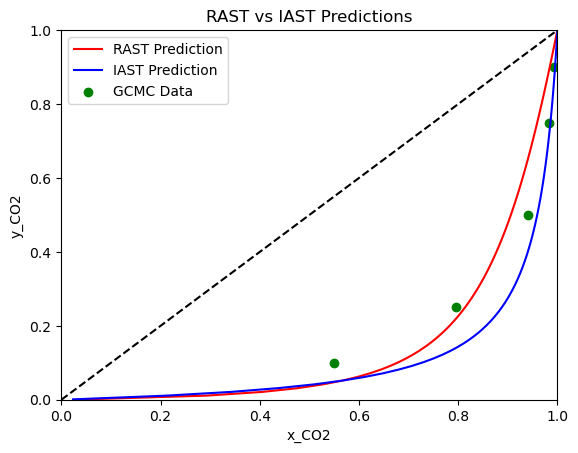

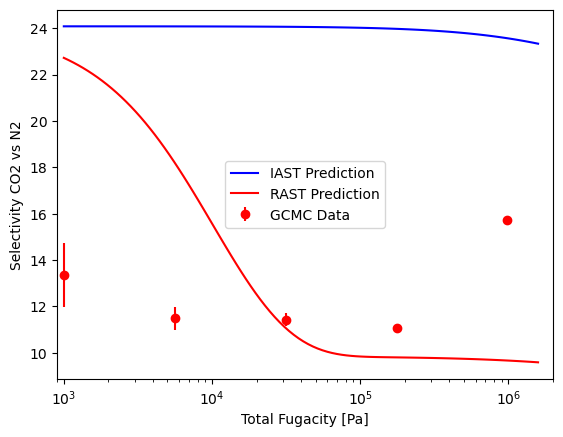

In [16]:
co2_isotherm = ModelIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]',
                             'CO2_fugacity[Pa]', model='Langmuir')
n2_isotherm = ModelIsotherm(n2_pure, 'N2_uptake_absolute[mol/kg]',
                            'N2_fugacity[Pa]', model='Langmuir')

partial_fug = np.array([co2_n2_binary['CO2_fugacity[Pa]'].values,
                        co2_n2_binary['N2_fugacity[Pa]'].values])
partial_fug = partial_fug.T
loadings = np.array([co2_n2_binary['CO2_uptake_absolute[mol/kg]'].values,
            co2_n2_binary['N2_uptake_absolute[mol/kg]'].values])
loadings = loadings.T
loadings = np.sum(loadings, axis=1)
isotherms = [co2_isotherm, n2_isotherm]
ac = ActivityCoefficient(partial_fug, loadings, isotherms, 'aNRTL', total_loading=True)
print(ac)

y_co2 = np.linspace(0.001, 0.999, 100)
total_f = 1e6
x = np.zeros(len(y_co2))
fig, ax = plt.subplots()

for i, y in enumerate(y_co2):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = rast(partial_fugacities, isotherms, ac)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_co2, label='RAST Prediction', color='red')

for i, y in enumerate(y_co2):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = iast(partial_fugacities, isotherms)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_co2, label='IAST Prediction', color='blue')

# Plot original data
data = co2_n2_binary[co2_n2_binary['total_pressure[Pa]'] == total_f]
x = data['CO2_uptake_absolute[mol/kg]']/(data['CO2_uptake_absolute[mol/kg]'] + data['N2_uptake_absolute[mol/kg]'])
y = data['y_co2']
ax.scatter(x, y, color='green', label='GCMC Data')

ax.set_xlabel('x_CO2')
ax.set_ylabel('y_CO2')
ax.legend()
ax.set_title('RAST vs IAST Predictions')
ax.axline((0, 0), slope=1, color='black', linestyle='--')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()

# 50/50 mixture selectivity
y = 0.5
fugacities = np.logspace(3, 6.2, 100)
selectivity = np.zeros(len(fugacities))
for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = iast(partial_fugacities, isotherms)
    selectivity[i] = (loadings[0] / loadings[1])
fig, ax = plt.subplots()
ax.plot(fugacities, selectivity, label='IAST Prediction', color='blue')
ax.set_xscale('log')
ax.set_xlabel('Total Fugacity [Pa]')
ax.set_ylabel('Selectivity CO2 vs N2')

for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = rast(partial_fugacities, isotherms, ac)
    selectivity[i] = (loadings[0] / loadings[1])
ax.plot(fugacities, selectivity, label='RAST Prediction', color='red')

# Plot original data
data = co2_n2_binary[co2_n2_binary['y_co2'] == y]
error1 = (data['CO2_uptake_absolute_uncertainty[mol/kg]'] / data['CO2_uptake_absolute[mol/kg]'])**2
error2 = (data['N2_uptake_absolute_uncertainty[mol/kg]'] / data['N2_uptake_absolute[mol/kg]'])**2
selectivity = data['CO2_uptake_absolute[mol/kg]'] / data['N2_uptake_absolute[mol/kg]']
error = selectivity * np.sqrt(error1 + error2)
ax.errorbar(data['CO2_fugacity[Pa]'] + data['N2_fugacity[Pa]'], selectivity,
            yerr=error, fmt='o', color='red', label='GCMC Data')
ax.legend()
ax.set_xlim(9e2, 2e6)

plt.show()


As you can see, fitting to total loading can be done just as easily as fitting to component loadings. Be careful though! The model parameters are very different compared to fitting to component loadings. While the x-y diagram is similar, the selectivity plot shows that the model fit to total loading is not as accurate in the pressure range we are looking at.

As our last demonstration, let's do a quick sanity check. Let's use a forward RAST calculation to predict the loadings of a mixture, and then use reverse RAST to see if we can recover the original mixture composition. This is a good way to check that the RAST calculations are working correctly.

In [17]:
co2_isotherm = CubicIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]',
                             'CO2_fugacity[Pa]', extrap_method='Langmuir')
n2_isotherm = CubicIsotherm(n2_pure, 'N2_uptake_absolute[mol/kg]',
                            'N2_fugacity[Pa]', extrap_method='Langmuir')

# Forward calculation
partial_fugacities = [5e5, 5e5]
isotherms = [co2_isotherm, n2_isotherm]
loadings = rast(partial_fugacities, isotherms, ac)
print(f"Predicted loadings: {loadings} mol/kg")

# Reverse calculation
adsorbed_fractions = loadings / np.sum(loadings)
total_fugacity = 1e6
print(f'Gas phase mole fractions: {reverse_rast(adsorbed_fractions, total_fugacity,
                                                isotherms, ac)[0]}')

Predicted loadings: [8.87495087 1.34759497] mol/kg
Gas phase mole fractions: [0.5 0.5]
